# BiLSTM, random split - two hyperparameter configurations

Mentor's ask: random validation split, two hyperparameter sets, result
saved to a file. This is the BiLSTM half of the three-model comparison
(the other two are `05_lightgbm_random_split.ipynb` and
`06_transformer_random_split.ipynb`).

**Scope note, stated up front:** the BiLSTM architecture here
(`models/bilstm.py`) is reconstructed from `docs/BILSTM_PARAMETERS.md`
(Parth's `bilstm` branch) line for line - same input projection, same
2-layer bidirectional LSTM, same attention pooling, same tabular encoder.
What's *not* carried over is the 6-channel rain cube that branch trains on
(`rain_mm`, `rain_anom_mm`, `in_interval`, `doy_sin`, `doy_cos`,
`wet_frac`); only this repo's single-channel `rain_seq.npz` (`rain_mm`)
was ever built here, and rebuilding the 6-channel pipeline is out of scope
for this pass. So this is the documented "BiLSTM, rain only" variant -
182,962 parameters at the default config, within a few hundred of the
transformer's 176,817 for the same reason Parth's doc gives: so a
difference in results isn't just a difference in capacity. It is also the
fairer comparison here specifically, since this repo's transformer has
also only ever seen `rain_mm`.

In [1]:
import sys
sys.path.insert(0, '../models')
import pandas as pd
import matplotlib.pyplot as plt
import train_random as tr
from transformer import count_params
from bilstm import BiLSTMModel

tr.CONFIGS['bilstm']

{'a': {'hidden': 64, 'layers': 2, 'lr': 0.002, 'bs': 512},
 'b': {'hidden': 32, 'layers': 2, 'lr': 0.001, 'bs': 512}}

## Config A - the documented default

Hidden size 64 per direction, 2 layers, peak lr 2e-3 (BILSTM_PARAMETERS.md
section 1/4). Up to 12 epochs, early stopping patience 4 on validation MAE
- both capped below the documented 25/patience-5 for wall-clock reasons on
a 2-core CPU box (no GPU here); noted so the numbers aren't read as the
fully-converged figures from that document.

In [2]:
res_a = tr.run_bilstm('a')
print('params:', res_a['params'], ' (document: 182,962 for the 1-channel variant)')
print('epochs run:', res_a['epochs_run'], ' valid:', res_a['valid'], ' test:', res_a['test'])

[bilstm-a] already in random_split_results.json - reusing it instead of retraining. Pass force=True to redo the run.
params: 182962  (document: 182,962 for the 1-channel variant)
epochs run: 12  valid: {'mae': 1.4130096435546875, 'rmse': 2.2299301624298096, 'r2': 0.5141214728355408}  test: {'mae': 1.4324530363082886, 'rmse': 2.25907039642334, 'r2': 0.4877985119819641}


## Config B - half the hidden size, the transformer's learning rate

Hidden 32, lr 1e-3. This directly answers two of the open items in
BILSTM_PARAMETERS.md section 7 in one run: "try 1e-3 ... on the rain-only
BiLSTM" (closing the stated learning-rate caveat against the transformer)
and "hidden size 32 and 128 ... to show the result is not sensitive to
capacity, not to beat it."

In [3]:
res_b = tr.run_bilstm('b')
print('params:', res_b['params'])
print('epochs run:', res_b['epochs_run'], ' valid:', res_b['valid'], ' test:', res_b['test'])

[bilstm-b] already in random_split_results.json - reusing it instead of retraining. Pass force=True to redo the run.
params: 52722
epochs run: 12  valid: {'mae': 1.4180582761764526, 'rmse': 2.2328104972839355, 'r2': 0.512865424156189}  test: {'mae': 1.439406394958496, 'rmse': 2.2722229957580566, 'r2': 0.48181700706481934}


## Comparing the two configs

In [4]:
rows = []
for name, r in [('bilstm-a (hidden 64, lr 2e-3)', res_a), ('bilstm-b (hidden 32, lr 1e-3)', res_b)]:
    rows.append(dict(config=name, params=r['params'], epochs_run=r['epochs_run'],
                      valid_mae=r['valid']['mae'], valid_r2=r['valid']['r2'],
                      test_mae=r['test']['mae'], test_r2=r['test']['r2'],
                      seconds=r['seconds']))
df = pd.DataFrame(rows)
df

,config,params,epochs_run,valid_mae,valid_r2,test_mae,test_r2,seconds
0,"bilstm-a (hidden 64, lr 2e-3)",182962,12,1.413010,0.514121,1.432453,0.487799,3619.3
1,"bilstm-b (hidden 32, lr 1e-3)",52722,12,1.418058,0.512865,1.439406,0.481817,1479.1


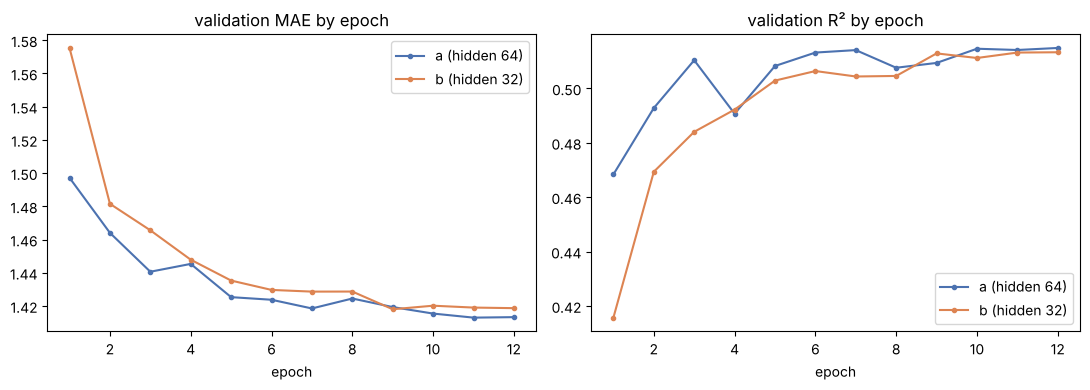

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for r, name, c in [(res_a, 'a (hidden 64)', '#4C72B0'), (res_b, 'b (hidden 32)', '#DD8452')]:
    h = pd.DataFrame(r['history'])
    ax[0].plot(h['epoch'], h['mae'], label=name, color=c, marker='o', ms=3)
    ax[1].plot(h['epoch'], h['r2'], label=name, color=c, marker='o', ms=3)
ax[0].set_title('validation MAE by epoch'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].set_title('validation R² by epoch'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout()
plt.savefig('../reports/figures/random_split_bilstm_curves.png', dpi=130)
plt.show()

**Reading this:** if config b (less than a third of the parameters)
lands close to config a, that's the capacity-insensitivity result
BILSTM_PARAMETERS.md section 7 predicted wanting to see - evidence the
~0.42-0.48 R² range this architecture reaches is set by the data and the
split, not by how large the LSTM is.

## Result

Both configs saved to `data/training/random_split_results.json` under
`bilstm-a` / `bilstm-b`, in the same file and same metric format as the
LightGBM and transformer notebooks, so the three can be compared directly
in `docs/RANDOM_SPLIT_COMPARISON.md`.